---
## Sorbonne Université
# <center> Mathématiques discrètes </center>
## <center> LU2IN005 </center>
## <div style="text-align:right;"> Année 2025-2026</div>
---

---
# <center> TME programmation d'automates finis </center>

L'objectif de ce TME est de programmer en python quelques uns des
algorithmes pour les automates finis vus en cours et en TD, en
utilisant des structures de données fournies dans le code mis à votre
disposition.
---
# Consignes

Copiez dans votre répertoire de travail les fichiers présents dans le Dossier 
*Fichiers Python fournis* de la page Moodle de l'UE.

Ils contiennent les définitions de structures de données décrites
ci-dessous, ainsi que des aide-mémoire sur l'utilisation de python.

**Le seul fichier que vous êtes autorisés à modifier** est 
`Projet_etudiant.ipynb`, partiellement prérempli. 
Les instructions `return` sont à supprimer lorsque
vous remplirez le contenu des différentes fonctions.  Les autres
fichiers n'ont pas besoin d'être lus (mais ils peuvent l'être).

---

Nom : DIALLO

 Prénom : Abdourahamane

N°_étudiant : 21415020

### Table des matières

> [1. Présentation](#sec1)
>> [1.1 La classe `State`](#sec1_1) <br>
>> [1.2 La classe `Transition`](#sec1_2) <br>
>> [1.3 La classe `Automate`](#sec1_3)

> [2. Prise en mains](#sec2)
>> [2.1 Création d'automates](#sec2_1) <br>
>> [2.2 Premières manipulations](#sec2_2) <br>

> [3. Exercices de base : tests et complétion](#sec3)

> [4. Déterminisation](#sec4)

> [5. Constructions sur les automates réalisant des opérations sur les langages acceptés](#sec5)
>> [5.1 Opérations ensemblistes sur les langages](#sec5_1) <br>
>> [5.2 Opérations rationnelles sur les langages](#sec5_2)

> [6. Application](#sec6)

In [1]:
## Import des bibliothèques nécessaires au projet.
## Ne pas modifier les fichiers "bibliothèque".

## Interpréter cette cellule avant de continuer.

from transition import *
from state import *
import os
import copy
from automateBase import AutomateBase
import itertools

class Automate(AutomateBase):
    pass

### 1. Présentation  <a class="anchor" id="sec1"></a>

Le projet utilise le langage python avec une syntaxe légèrement
différente de celle vue en **LU1IN001 / 011**, parce qu'il exploite en particulier
la notion de classes d'objets. Une introduction à cette notion est présentée dans le livre associé
au cours : cf [Chapitre 13](https://www-licence.ufr-info-p6.jussieu.fr/lmd/licence/2021/ue/LU1IN001-2021oct/cours2020.pdf).

De plus, le typage des variables est noté de façon légèrement différente, en commentaires, pour les déclarations
comme pour les arguments des fonctions. Pour ces derniers, les types sont indiqués dans la première ligne de la documentation de la fonction.

Les particularités sont brièvement expliquées en annexe
de ce document. Par ailleurs, vous trouverez dans la section
`projet` de la page Moodle un mémo sur la syntaxe python, ainsi que la carte de
référence du langage utilisée en **LU1IN001 / 011**.  On rappelle qu'une ligne
commençant par `#` est un commentaire, ignoré par
l'interpréteur.

Toutes les structures de données nécessaires à la construction des
automates sont fournies sous la forme de classes python, pour les
transitions d'un automate, ses états, et les automates
eux-mêmes. Cette section indique comment les utiliser.

#### 1.1 La classe `State` <a class="anchor" id="sec1_1"></a>

Un état est représenté par
- un entier `id` (type `int`) qui définit son identifiant,
- un booléen `init` (type `bool`) indiquant si c'est un état initial,
- un booléen `fin` (type `bool`) indiquant si c'est un état final,
- une chaîne de caractères `label` (type `str`) qui définit son étiquette, permettant de le *décorer*. Par défaut, cette variable est la version chaîne de caractères de l'identifiant de l'état. 

On définit l'alias de type `State` pour représenter les variables de ce type. 

Ainsi, l'instruction ci-dessous crée une variable `s` représentant un état d'identifiant `1`, qui est un état initial mais pas final, dont l'identifiant et l'étiquette  `1` :

In [2]:
# s : State
s = State(1, True, False)

Si l'on souhaite avoir une étiquette différente de l'identifiant, on
utilise un quatrième argument :

In [3]:
s = State(1, True, False, 'etat 1') 

On accède ensuite aux différents champs de `s` par la notation pointée : exécutez les cellules suivantes pour observer l'affichage obtenu.

In [4]:
print('La valeur de s.id est : ')
print(s.id)

La valeur de s.id est : 
1


In [5]:
print('La valeur de s.init est : ')
print(s.init)

La valeur de s.init est : 
True


In [6]:
print('La valeur de s.fin est : ')
print(s.fin)

La valeur de s.fin est : 
False


In [7]:
print('La valeur de s.label est : ')
print(s.label)

La valeur de s.label est : 
etat 1


In [8]:
print("L'affichage de s est : ")
print(s)

L'affichage de s est : 
etat 1(init)


Ainsi, une variable de type `State` est affichée par son étiquette et, entre parenthèses, si c'est un état initial et/ou final.

#### 1.2 La classe `Transition` <a class="anchor" id="sec1_2"></a>

Une transition est représentée par 
- un état `stateSrc` (type `State`) correspondant à son état de départ
- un caractère `etiquette` (type `str`) donnant son   étiquette
- un état `stateDest` (type `State`) correspondant à son état de destination

On définit l'alias de type `Transition` pour représenter les variables de ce type.

La séquence d'instructions suivante crée la transition d'étiquette `"a"` de l'état `s` (défini ci-dessus) vers lui-même et affiche les différents champs de la transition :

In [9]:
# t : Transition
t = Transition(s, "a", s)

In [10]:
print('La valeur de t.etiquette est : ')
print(t.etiquette)

La valeur de t.etiquette est : 
a


In [11]:
print("L'affichage de t.stateSrc est : ")
print(t.stateSrc)

L'affichage de t.stateSrc est : 
etat 1(init)


On remarque que la variable `stateSrc` est de type `State`, on obtient donc un état, et non uniquement un
identifiant d'état. 

In [12]:
print("L'affichage de t.stateDest est : ")
print(t.stateDest)

L'affichage de t.stateDest est : 
etat 1(init)


In [13]:
print("L'affichage de t est : ")
print(t)

L'affichage de t est : 
[etat 1(init)-a->etat 1(init)]


#### 1.3 La classe `Automate` <a class="anchor" id="sec1_3"></a>

Un automate est représenté par
- l'ensemble de ses transitions `allTransitions` (de type `set[Transition]`) 
- l'ensemble de ses états `allStates` (de type `set[State]`)
- une étiquette `label` (de type `str`) qui est éventuellement vide.

On définit l'alias de type `Automate` pour représenter les variables de ce type.

Ainsi, de même que pour les classes précédentes, l'accès aux
différents champs se fait par la notation pointée. Par exemple, on
obtient l'ensemble des états d'un automate `monAutomate` par
l'instruction `monAutomate.allStates`.

Pour créer un automate, il existe trois possibilités.

**Création à partir d'un ensemble de transitions.**<br>
On peut d'abord utiliser le constructeur de signature `Automate : set[Transition] -> Automate`.<br>
Il déduit alors l'ensemble des états à partir de l'ensemble des transitions et définit par défaut l'étiquette
de l'automate comme la chaîne de caractères vide.

Par exemple, en commençant par créer les états et les transitions nécessaires :

In [14]:
## création d'états
# s1 : State
s1 = State(1, True, False)
# s2 : State
s2 = State(2, False, True)

## création de transitions
# t1 : Transition
t1 = Transition(s1,"a",s1)
# t2 : Transition
t2 = Transition(s1,"a",s2)
# t3 : Transition
t3 = Transition(s1,"b",s2)
# t4 : Transition
t4 = Transition(s2,"a",s2)
# t5 : Transition
t5 = Transition(s2,"b",s2)
# set_transitions : set[Transition]
set_transitions = {t1, t2, t3, t4, t5}

## création de l'automate
# aut : Automate
aut = Automate(set_transitions)

L'affichage de cet automate, par la commande `print(aut)` produit alors le résultat suivant : 

In [15]:
print(aut)

Etats :
  1(init)
  2(fin)
Transitions :
  [1(init)-b->2(fin)]
  [1(init)-a->1(init)]
  [2(fin)-a->2(fin)]
  [1(init)-a->2(fin)]
  [2(fin)-b->2(fin)]



Les états de l'automate sont déduits de l'ensemble de transitions.

Optionnellement, on peut donner un nom à l'automate, en utilisant la variable `label`, par exemple :

In [16]:
# aut2 : Automate
aut2 = Automate(set_transitions, label="A") 

print(aut2)

Automate A
Etats :
  1(init)
  2(fin)
Transitions :
  [1(init)-b->2(fin)]
  [1(init)-a->1(init)]
  [2(fin)-a->2(fin)]
  [1(init)-a->2(fin)]
  [2(fin)-b->2(fin)]



**Création à partir d'un ensemble de transitions et d'un ensemble d'états.**<br>
Dans le second cas, on crée un automate à partir d'un ensemble de
transitions mais aussi d'un ensemble d'états, par exemple pour représenter des
automates contenant des états isolés. Pour cela, on utilise le
constructeur `Automate : set[Transition] x set[State] -> Automate`.

On peut également, optionnellement, donner un nom à l'automate :

In [17]:
# set_etats : set[State]
set_etats = {s1, s2}

# aut3 : Automate
aut3 = Automate(set_transitions, set_etats,"B")

print(aut3)

Automate B
Etats :
  1(init)
  2(fin)
Transitions :
  [1(init)-b->2(fin)]
  [1(init)-a->1(init)]
  [2(fin)-a->2(fin)]
  [1(init)-a->2(fin)]
  [2(fin)-b->2(fin)]



L'ordre des paramètres peut ne pas être respecté **à la condition** que l'on donne leur nom explicitement. Ainsi, la ligne suivante est correcte :

In [18]:
aut = Automate(setStates = set_etats, label = "A", setTransitions = set_transitions)

print(aut)

Automate A
Etats :
  1(init)
  2(fin)
Transitions :
  [1(init)-b->2(fin)]
  [1(init)-a->1(init)]
  [2(fin)-a->2(fin)]
  [1(init)-a->2(fin)]
  [2(fin)-b->2(fin)]



**Création à partir d'un fichier contenant sa description.**<br>
La fonction `Automate.creationAutomate : str -> Automate` prend en argument un nom de fichier qui décrit un automate et construit l'automate correspondant (voir exemple ci-dessous).

La description textuelle de l'automate doit suivre le format suivant (voir exemple ci-dessous) :
- #E: suivi de la liste des noms des états, séparés par
  des espaces ou des passages à la ligne. Les noms d'états peuvent
  être n'importe quelle chaîne alphanumérique pouvant également
  contenir le symbole `_`. Par contre, si le nom d'état
  contient des symboles *non numériques* il ne doit pas commencer
  par un chiffre, sous peine de provoquer une erreur à l'affichage.
  Ainsi, `10` et `A1` sont des noms d'états possibles,
  mais `1A` ne l'est pas.
- #I: suivi de la liste des états initiaux
  séparés par des espaces ou des passages à la ligne, 
- #F: suivi de la liste des
  états finaux séparés par des espaces ou des passages à la ligne, 
- #T: suivi de la liste des transitions séparées par des
  espaces ou des passages à la ligne. Chaque transition est donnée
  sous le format `(etat1, lettre, etat2)`.

Par exemple le fichier `exempleAutomate.txt` contenant <br>
`#E: 0 1 2 3`<br>
`#I: 0`<br>
`#F: 3`<br>
`#T: (0 a 0)`<br>
`	(0 b 0)`<br>
`	(0 a 1)`<br>
`	(1 a 2)`<br>
`	(2 a 3)`<br>
`	(3 a 3)`<br>
`	(3 b 3)`<br>
est formaté correctement. L'appel suivant produira l'affichage...

In [19]:
# automate : Automate
automate = Automate.creationAutomate("ExemplesAutomates/exempleAutomate.txt")
print(automate)

Etats :
  0(init)
  1
  2
  3(fin)
Transitions :
  [2-a->3(fin)]
  [0(init)-a->0(init)]
  [3(fin)-a->3(fin)]
  [3(fin)-b->3(fin)]
  [0(init)-a->1]
  [0(init)-b->0(init)]
  [1-a->2]



**Fonctions de manipulation des automates.**<br>
La classe automate contient également de nombreuses fonctions utiles. Elles
s'appliquent à un objet de type `Automate` et s'utilisent donc sous la forme
`aut.<`*fonction*`>(<`*parametres*`>)` où `aut` est une variable de type `Automate`.


- `show : float -> NoneType` <br> 
    prend en argument facultatif un flottant (facteur de grossissement, par défaut il vaut 1.0) et produit une représentation graphique de l'automate.<br>
    Ainsi, en utilisant l'automate défini dans le fichier d'exemple précédent, l'instruction `automate.show(1.2)` produit l'image suivante :

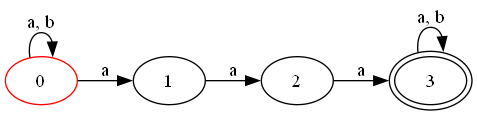

In [20]:
automate.show(1.2)

- `addTransition : Transition -> bool`<br>
  prend en argument une transition `t`, fait la mise à jour de
  l'automate en lui ajoutant `t` et ajoute les états impliqués
  dans l'automate s'ils en sont absents. Elle rend `True` si l'ajout a
  eu lieu, `False` sinon (si `t` était déjà présente dans l'automate).
  
- `removeTransition : Transition -> bool`<br>
  prend en argument une transition `t` et fait la mise à jour de
  l'automate en lui enlevant la transition, sans modifier les
  états. Elle rend `True` si la suppression a eu lieu, `False` sinon (si
  `t` était absente de l'automate).

- `addState : State -> bool`<br>
  prend en argument un état `s` et fait la mise à jour de
  l'automate en lui ajoutant `s`.  Elle rend `True` si l'ajout a eu
  lieu, `False` sinon (si `s` était déjà présent dans l'automate).

- `nextId : -> int`<br>
  renvoie un entier id frais, en choisissant l'entier le plus petit,
  strictement supérieur à tous les id des états de l'automate.

- `removeState : State -> bool`<br>
  prend en argument un état `s` et fait la mise à jour de
  l'automate en supprimant `s` ainsi que toutes ses transitions
  entrantes et sortantes.  Elle rend `True` si l'ajout a eu lieu, `False`
  sinon (si `s` était absent de l'automate).
  
- `getSetInitialStates :  -> set[State]`<br> 
  rend l'ensemble des états initiaux.

- `getSetFinalStates :  -> set[State]`<br>
  rend l'ensemble des états finaux.

- `getSetTransitionsFrom : State -> set[Transition]`<br>
  rend l'ensemble des transitions sortant de l'état passé en argument.

- `prefixStates : int -> NoneType`<br>
  modifie les identifiants et les étiquettes de tous les états de
  l'automate en les préfixant par l'entier passé en argument.

- `succElem : State x str -> set[State]`<br>
  étant donné un état `s` et un caractère `a`, elle rend l'ensemble des
  états successeurs de `s` par le caractère `a`.  Formellement,
  
  $$succElem(s, a) = \{s' \in S \mid  s \xrightarrow{a} s'\}.$$
  
  Cet ensemble peut contenir plusieurs états si l'automate n'est pas déterministe.

In [21]:
# Voilà le code de succElem

def succElem(self, state, lettre):
    """ State x str -> set[State]
        rend l'ensemble des états accessibles à partir d'un état state par l'étiquette lettre
    """
    successeurs = set()
    # t: Transitions
    for t in self.getSetTransitionsFrom(state):
        if t.etiquette == lettre:
            successeurs.add(t.stateDest)
    return successeurs

Automate.succElem = succElem

Avec l'exemple précédent, on obtient :

In [22]:
s0 = list(automate.getSetInitialStates())[0] ## on récupère l'état initial de automate
automate.succElem(s0, 'a')

{0(init), 1}

### 2. Prise en mains  <a class="anchor" id="sec2"></a>

#### 2.1 Création d'automates <a class="anchor" id="sec2_1"></a>

Soit l'automate $\mathcal{A}$ défini sur l'alphabet $\{ a,b \}$, d'états $0,1,2$, 
d'état initial 0, d'état final 2 et de transitions : <br>$(0,a,0)$, $(0,b,1)$, 
$(1,a,2)$, $(1,b,2)$, $(2,a,0)$ et $(2,b,1)$.

1. Créer l'automate $\mathcal{A}$ à l'aide de son ensemble de transitions. Pour cela, créer un état `s0`  
d'identifiant $0$
  qui soit initial, un état `s1` d'identifiant $1$ et un état
  `s2` d'identifiant $2$ qui soit final. Puis créer `t1`, `t2`, `t3`, `t4`, `t5` et
  `t6` les 6 transitions de l'automate. Créer enfin l'automate
  `auto` à partir de ses transitions, par exemple avec l'appel<br>
  `auto = Automate({t1,t2,t3,t4,t5,t6})`.<br>
  Vérifier que l'automate correspond bien à $\mathcal{A}$ en l'affichant.

Etats :
  0(init)
  1
  2(fin)
Transitions :
  [0(init)-a->0(init)]
  [1-a->2(fin)]
  [2(fin)-b->1]
  [2(fin)-a->0(init)]
  [1-b->2(fin)]
  [0(init)-b->1]



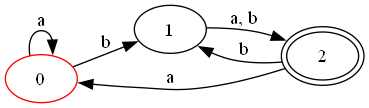

In [23]:
# A faire par l'étudiant
# Créations d'états
s0 = State(0,True,False)
s1 = State(1,False,False)
s2 = State(2,False,True)
# Créations des transitions
t1 = Transition(s0,"a",s0)
t2 = Transition(s0,"b",s1)
t3 = Transition(s1,"a",s2)
t4 = Transition(s1,"b",s2)
t5 = Transition(s2,"a",s0)
t6 = Transition(s2,"b",s1)
# création de l'automate 
auto = Automate({t1,t2,t3,t4,t5,t6})
# Affichage avec print puis show
print(auto)
auto.show(1.2)

2. Créer l'automate $\mathcal{A}$ à l'aide de sa liste de
  transitions et d'états, par exemple à l'aide de l'appel<br>
  `auto1 = Automate({t1,t2,t3,t4,t5,t6}, {s0,s1,s2})`<br>
  puis afficher l'automate obtenu à l'aide de `print` puis à l'aide de `show`.
  Vérifier que l'automate `auto1` est bien
  identique à l'automate `auto`.

Automate auto1
Etats :
  0(init)
  1
  2(fin)
Transitions :
  [0(init)-a->0(init)]
  [1-a->2(fin)]
  [2(fin)-b->1]
  [2(fin)-a->0(init)]
  [1-b->2(fin)]
  [0(init)-b->1]



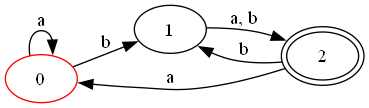

In [24]:
# A faire par l'étudiant
#Céation de l'automate 
auto1 = Automate({t1,t2,t3,t4,t5,t6}, {s0,s1,s2}, label = "auto1")
# Affichage avec print
print(auto1)
# Affichage avec show
auto1.show(1.2)

3. Créer l'automate $\mathcal{A}$ à partir d'un fichier. Pour cela,
  créer un fichier `auto2.txt`, dans lequel sont indiqués les
  listes des états et des transitions, ainsi que l'état initial et
  l'état final, en respectant la syntaxe donnée dans la section
  précédente. Par exemple la liste d'états est décrite par la ligne
  `#E: 0 1 2`.  Utiliser ensuite par exemple l'appel
  `auto2 = Automate.creationAutomate("ExemplesAutomates/auto2.txt")`, puis afficher
  l'automate `auto2` à l'aide de `print` ainsi qu'à l'aide de `show`.

Etats :
  0(init)
  1
  2(fin)
Transitions :
  [0(init)-a->0(init)]
  [1-a->2(fin)]
  [2(fin)-b->1]
  [2(fin)-a->0(init)]
  [1-b->2(fin)]
  [0(init)-b->1]



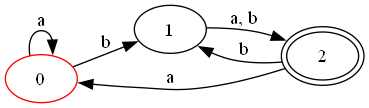

In [25]:
# A faire par l'étudiant
# Création de l'automate 
auto2 = Automate.creationAutomate("ExemplesAutomates/auto2.txt")
# Affichage avec print 
print(auto2)
# Affichage avec show
auto2.show(1.2)


#### 2.2 Premières manipulations <a class="anchor" id="sec2_2"></a>

1. Appeler la fonction `removeTransition` sur l'automate
  `auto` en lui donnant en argument la transition $(0,a,1)$. Il
  s'agit donc de créer une variable `t` de type
  `Transition` représentant $(0,a,1)$ et d'effectuer l'appel
  `auto.removeTransition(t)`. Observer le résultat sur un
  affichage.  Appeler ensuite cette fonction sur `auto` en lui
  donnant en argument la transition `t1`. Observer le résultat
  sur un affichage. Appeler la fonction `addTransition` sur
  l'automate `auto` en lui donnant en argument la transition
  `t1`. Vérifier que l'automate obtenu est bien le même
  qu'initialement.

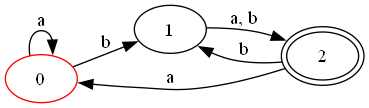

In [26]:
# A faire par l'étudiant
# on créé une transition et on la supprime après 
t = Transition(s0,"a",s1)
auto.removeTransition(t)
auto.show(1.2) 
# on remarque que, notre automate n'a pas changé 

Suppression de t1


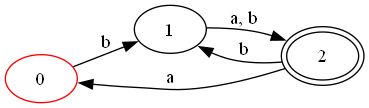

L'ajout de t1


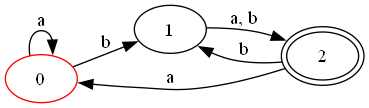

In [27]:
# A faire par l'étudiant
# on supprime la transition t1
auto.removeTransition(t1)
print("Suppression de t1")
auto.show(1.2)
# On ajoute la transition t1
auto.addTransition(t1)
print("L'ajout de t1")
auto.show(1.2)

2. Appeler la fonction `removeState` sur l'automate
  `auto` en lui donnant en argument l'état
  `s1`. Observer le résultat. Appeler la fonction
  `addState` sur l'automate `auto` en lui donnant en
  argument l'état `s1`. Créer un état `s0bis` d'identifiant
  $0$ et initial. Appeler la fonction `addState` sur
  `auto` avec `s0bis` comme argument. Observer le résultat.

Après suppression de s1


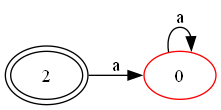

Après l'ajout de s1


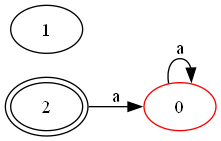

Après l'ajout de s0bis à auto


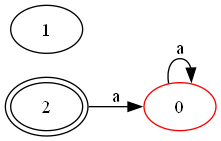

In [28]:
# A faire par l'étudiant
# on supprime l'état s1 de auto
print("Après suppression de s1")
auto.removeState(s1)
# Affichage 
auto.show()
# on ajoute l'état s1 à auto
print("Après l'ajout de s1")
auto.addState(s1)
# Affichage
auto.show()
# Création d'un état
s0bis = State(0,True,False)
# ajout de s0bis à auto
print("Après l'ajout de s0bis à auto")
auto.addState(s0bis)
# Affichage
auto.show()
# Rémarque : on constate que le l'automate ne montre aucun changement, car on avait déjà un état initial 

3. Appeler la fonction `getSetTransitionsFrom` sur
  l'automate `auto1` avec `s1` comme argument. Afficher
  le résultat.

In [29]:
# A faire par l'étudiant
# cette fonction rend les transitions sortant de l'état s1
print("Ensemble des transitions sortant de l'état s1 pour l'automate auto1 est : ",auto1.getSetTransitionsFrom(s1))

Ensemble des transitions sortant de l'état s1 pour l'automate auto1 est :  {[1-a->2(fin)], [1-b->2(fin)]}


### 3. Exercices de base : tests et complétion  <a class="anchor" id="sec3"></a>

1. Donner une définition de la fonction `succ`
  qui, étant donné un ensemble d'états $S$ et une chaîne de caractères
      $a$ (de longueur 1), renvoie l'ensemble des états successeurs de tous les états de $L$ par le caractère $a$. Cette fonction doit généraliser la fonction `succElem` pour qu'elle prenne en paramètre un ensemble d'états au lieu d'un seul état.  Formellement, si $S$ est un ensemble d'états et $a$ une lettre,
  $$succ(S,a) = \bigcup_{s \in S}succ(s,a) = \{s' \in S \mid \text{il existe } s \in L \text{ tel que } s \xrightarrow{a} s'\}.$$

In [30]:
# A faire par l'étudiant
def succ(self, setStates, lettre):
    """ Automate x set[State] x str -> set[State]
        rend l'ensemble des états accessibles à partir de l'ensemble d'états setStates par l'étiquette lettre
    """
    # Initialiser l'ensemble des états accessibles
    ens_successeurs=set()
    
    # Parcourir chaque état dans l'ensemble donné
    for state in setStates:
       # Utiliser succElem pour trouver les états accessibles à partir de l'état actuel
       ens_successeurs.update(succElem(self, state, lettre)) # update fait l'union des deux ensembles
    return ens_successeurs

Automate.succ = succ

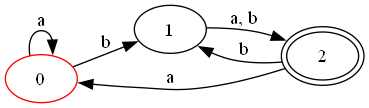

---


In [31]:
# On a défini auparavant un automate auto1, voilà les résultats le concernant, puis un jeu de tests :
auto1.show()
print('---')
assert auto1.succ({s0, s2}, 'b') == {s1}
assert auto1.succ({s0}, 'a') == {s0}
assert auto1.succ({s0, s1}, 'a') == {s0, s2}

In [32]:
# Fournir un autre jeu de tests
assert auto1.succ({s0},'b') == {s1}
assert auto1.succ({s1},'a') == {s2}
assert auto1.succ({s2},'a') == {s0}
assert auto1.succ({s0, s1, s2},'a') == {s0,s2}
assert auto1.succ({s2},'b') == {s1}

2. Donner une définition de la fonction `accepte`
  qui, étant donné une chaîne de caractères `mot`,
  renvoie un booléen qui vaut vrai si et seulement si `mot` est accepté par l'automate. Attention, noter que l'automate peut ne pas être déterministe.

In [33]:
# A faire par l'étudiant

def accepte(self, mot) :
    """ Automate x str -> bool
        rend True si auto accepte mot, False sinon
    """
    etats = self.getSetInitialStates() 
    etats_finaux = self.getSetFinalStates()
    
    for lettre in mot:
        etats = self.succ(etats, lettre)
        if not etats: 
            return False
    return any(state in etats_finaux for state in etats)
    
Automate.accepte = accepte

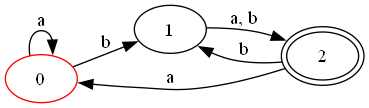

---


In [34]:
# On a défini auparavant un automate auto1, voilà les résultats le concernant, puis un jeu de tests :

auto1.show()
print('---')
assert auto1.accepte('aa') == False
assert auto1.accepte('ab') == False
assert auto1.accepte('aba') == True


In [35]:
# Fournir un autre jeu de tests
assert auto1.accepte('ba') == True
assert auto1.accepte('bb') == True
assert auto1.accepte('abb') == True
assert auto1.accepte('bbb') == False
assert auto1.accepte('aaa') == False
assert auto1.accepte('abbabba') == False
assert auto1.accepte('ababaabb') == True

3. Donner une définition de la fonction `estComplet`
    qui, étant donné un automate `auto` et un ensemble de caractères `Alphabet`
    renvoie un booléen qui vaut vrai si et
    seulement si `auto` est complet par rapport à l'alphabet.
    
    On n'effectuera pas la vérification sur les états non accessibles.

In [36]:
# A faire par l'étudiant

### On ne prend pas en compte les états non accessibles
def estComplet(self, Alphabet) :
    """ Automate x set[str] -> bool
        rend True si auto est complet pour les lettres de Alphabet, False sinon
        hyp : les éléments de Alphabet sont de longueur 1
    """
    for state in self.allStates:
        transitions = {t.etiquette for t in self.getSetTransitionsFrom(state)}
        if not transitions.issuperset(Alphabet): # on regarde s'il y a une transition pour chaque lettre d'Alphabet 
            return False
    return True

Automate.estComplet = estComplet

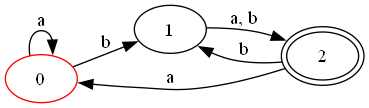

---


In [37]:
# On a défini auparavant un automate auto1, voilà les résultats le concernant, puis un jeu de tests :
auto1.show()
print('---')
assert auto1.estComplet({'a', 'b'}) == True
assert auto1.estComplet({'a', 'c', 'b'}) == False

On supprime la transition (0, 'a', 0)



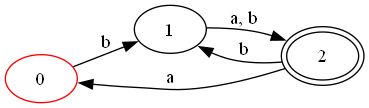

On supprime la transition (2, 'b', 1)



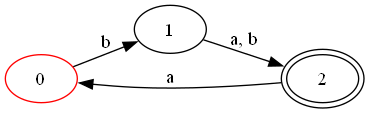

On les rajoute



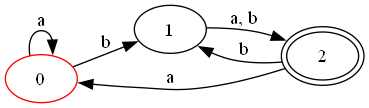

In [38]:
# Fournir un autre jeu de tests

# on supprime la transition t1
print("On supprime la transition (0, 'a', 0)\n")
auto1.removeTransition(t1)
auto1.show(1.2)
assert auto1.estComplet({'a', 'b'}) == False
assert auto1.estComplet({'b'}) == True

# on supprime la transition t6
print("On supprime la transition (2, 'b', 1)\n")
auto1.removeTransition(t6)
auto1.show(0.7)
assert auto1.estComplet({'b'}) == False
assert auto1.estComplet({'a'}) == False

# on ajoute les transitions t1 et t6
print("On les rajoute\n")
auto1.addTransition(t1)
auto1.addTransition(t6)
auto1.show(0.7) 
assert auto1.estComplet({'a','b'}) == True


4. Donner une définition de la fonction `estDeterministe`
qui, étant donné un automate `auto`,
 renvoie un booléen qui vaut vrai si et seulement si `auto` est déterministe.

In [39]:
# A faire par l'étudiant

def estDeterministe(self):
    """ Automate -> bool
        rend True si l'automate est déterministe, False sinon.
    """
    # On vérifie qu'il n'y a qu'un seul état initial
    if len(self.getSetInitialStates()) != 1:
        return False
    
    # On regarde si chaque état a au plus une transition pour chaque lettre
    for state in self.allStates:
        transitions_lettre = {} # dictionnaire avec pour clés les lettres et pour valeurs les transitions correspondantes
        for t in self.getSetTransitionsFrom(state):
            if t.etiquette in transitions_lettre:
                return False  # Pas déterministe s'il y a plusieurs transitions pour une lettre
            transitions_lettre[t.etiquette] = t
    return True

Automate.estDeterministe = estDeterministe

L'appel de fonction `copy.deepcopy(auto)` renvoie un nouvel automate identique à `auto`.

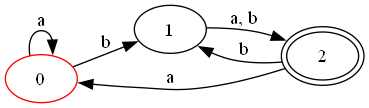

---


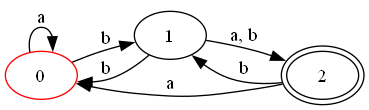

---


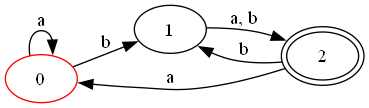

---


In [40]:
# On a défini auparavant un automate auto1, voilà les résultats le concernant, puis un jeu de tests :

auto1.show()
print('---')
assert auto1.estDeterministe() == True

auto1bis = copy.deepcopy(auto1)
#t : Transition
t = Transition(s1, 'b', s0)
auto1bis.addTransition(t)
auto1bis.show()
print('---')
assert auto1bis.estDeterministe() == False

auto1bis.removeTransition(t)
auto1bis.show()
print('---')
assert auto1bis.estDeterministe() == True

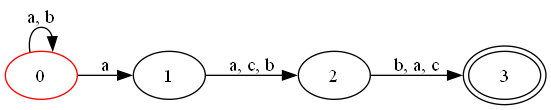

auto_test est déterministe : 
False

On supprime la transition (0, 'a', 0)



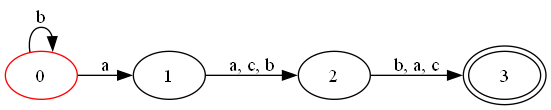

auto_test est déterministe : 
True
---


In [41]:
# Fournir un autre jeu de tests
# on créé un automate pour effectuer un test
## création d'états
S0 = State(0, True, False)
S1 = State(1, False, False)
S2 = State(2, False, False)
S3 = State(3, False, True)

## création de transitions
T1 = Transition(S0,"a",S0)
T2 = Transition(S0,"b",S0)
T3 = Transition(S0,"a",S1)
T4 = Transition(S1,"a",S2)
T5 = Transition(S1,"b",S2)
T6 = Transition(S1,"c",S2)
T7 = Transition(S2,"a",S3)
T8 = Transition(S2,"b",S3)
T9 = Transition(S2,"c",S3)

set_transitions_test = {T1,T2,T3,T4,T5,T6,T7,T8,T9}

## création de l'automate
auto_test = Automate(set_transitions_test)
auto_test.show()

## On teste s'il est déterministe ou pas :
print("auto_test est déterministe : ")
print(auto_test.estDeterministe())

## On enlève la transition (S0, "a", S0)
print("\nOn supprime la transition (0, 'a', 0)\n")
auto_test.removeTransition(T1)
auto_test.show()

## On teste s'il est déterministe ou pas :
print("auto_test est déterministe : ")
print(auto_test.estDeterministe())

auto_test.addTransition(T1)
print('---')

5. Donner une définition de la fonction `completeAutomate`
qui, étant donné un automate `auto` et l'ensemble alphabet d'entrée `Alphabet`,
renvoie l'automate complété d'`auto`.
  
Attention, il ne faut pas modifier `auto`, mais construire un nouvel automate.
<br>Il pourra être intéressant d'utiliser l'appel de fonction
`copy.deepcopy(auto)` qui renvoie un nouvel automate identique à `auto`.
<br>On pourra faire appel à la fonction `nextId` afin de construire l'état $\bot$.

In [42]:
# A faire par l'étudiant
def completeAutomate(self, Alphabet) :
    """ Automate x str -> Automate
        rend l'automate complété de self, par rapport à Alphabet
    """
    auto_copy = copy.deepcopy(self)
    sink_state_added = False
    sink_state = State(auto_copy.nextId(), False, False, "P")  # Etat puits P pour les transitions manquantes

    # On travaille sur une copie de l'automate pour éviter de modifier l'original
    for state in list(auto_copy.allStates):
        transitions = {t.etiquette for t in auto_copy.getSetTransitionsFrom(state)}
        missing_letters = Alphabet - transitions
        for letter in missing_letters:
            sink_state_added = True
            auto_copy.addTransition(Transition(state, letter, sink_state))
    
    # On ajoute les transitions de l'état puits pour toutes les lettres
    if sink_state_added:
        for letter in Alphabet:
            auto_copy.addTransition(Transition(sink_state, letter, sink_state))
        auto_copy.addState(sink_state)
    
    return auto_copy

Automate.completeAutomate = completeAutomate

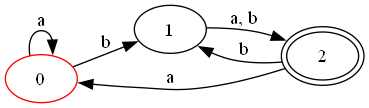

---


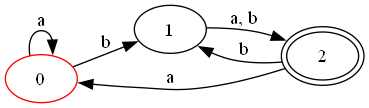

---


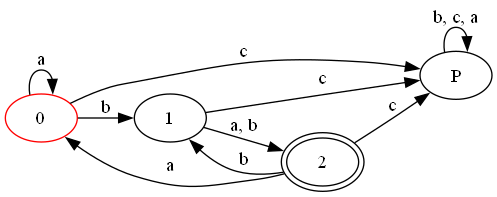

In [43]:
# On a défini auparavant un automate auto1, voilà les résultats le concernant :

auto1.show()
print('---')
assert auto1.estComplet({'a', 'b'}) == True
auto1complet = auto1.completeAutomate({'a', 'b'})
auto1complet.show()
assert auto1complet.estComplet({'a', 'b'}) == True

print('---')
assert auto1.estComplet({'a', 'b', 'c'}) == False
auto1complet = auto1.completeAutomate({'a', 'b', 'c'})
auto1complet.show()
assert auto1complet.estComplet({'a', 'b','c'}) == True

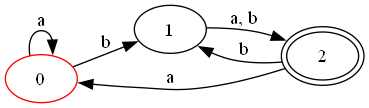

On supprime la transition (0, 'a', 0)



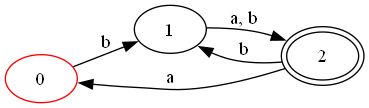

Voici le résultat de auto1.completeAutomate({'a', 'b'})



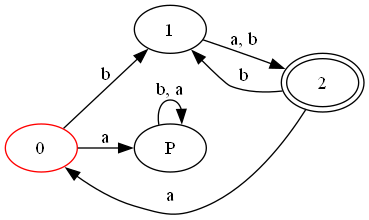

---


In [44]:
# Fournir un autre jeu de tests
auto1.show()
# on supprime la transition t1
print("On supprime la transition (0, 'a', 0)\n")
auto1.removeTransition(t1)
auto1.show()
assert auto1.estComplet({'a', 'b'}) == False
auto1complet = auto1.completeAutomate({'a', 'b'})

print("Voici le résultat de auto1.completeAutomate({'a', 'b'})\n")
auto1complet.show()
assert auto1complet.estComplet({'a', 'b'}) == True

# on rajoute la transition t1
auto1.addTransition(t1)
print('---')


### 4. Déterminisation  <a class="anchor" id="sec4"></a>

1. Donner une définition de la fonction `newLabel`
qui, étant donné un ensemble d'états renvoie une chaine de caractères représentant l'ensemble de tous les labels des états.
Par exemple, l'appel de `newLabel` sur un ensemble de 3 états dont les labels sont `'1', '2', '3'` renvoie `'{1,2,3}'`

Afin d'être assuré que l'ordre de parcours de l'ensemble des états n'a pas d'importance, il sera nécessaire de trier par ordre alphabétique la liste des `label` des états. On pourra faire appel à `L.sort()` qui étant donné la liste `L` de cha^nes de caractères, la trie en ordre alphabétique.

In [45]:
# A faire par l'étudiant
def newLabel(S):
    """ set[State] -> str
    """
    # Extraire les labels des états
    labels = [state.label for state in S]
    
    # Trier les labels par ordre alphabétique
    labels.sort()
    
    # Construire la chaîne de caractères au format '{label1,label2,...}'
    return "{" + ",".join(labels) + "}" # la méthode join permet de concaténer les labels triés en une chaîne unique

In [46]:
# On a défini auparavant un automate auto1, voilà les résultats le concernant, puis un jeu de tests :

assert newLabel(auto1.allStates) == '{0,1,2}'

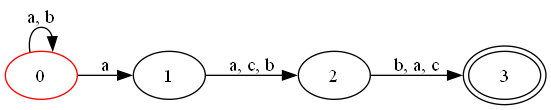

Ensemble des labels des états : {0,1,2,3}


In [47]:
# Fournir un autre jeu de tests
auto_test.show()
print("Ensemble des labels des états : " + newLabel(auto_test.allStates))

La fonction suivante permet de déterminiser un automate. On remarque qu'un état peut servir de clé dans un dictionnaire.

In [48]:
def determinisation(self) :
    """ Automate -> Automate
    rend l'automate déterminisé d'auto """
    # Ini : set[State]
    Ini = self.getSetInitialStates()
    # fin : bool
    fin = False
    # e : State
    for e in Ini:
        if e.fin:
            fin = True
    lab = newLabel(Ini)
    s = State(0, True, fin, lab)
    A = Automate(set())
    A.addState(s)
    Alphabet = {t.etiquette for t in self.allTransitions}
    Etats = dict()
    Etats[s] = Ini
    A.determinisation_etats(self, Alphabet, [s], 0, Etats, {lab})
    return A

Automate.determinisation = determinisation

L'automate déterminisé est construit dans `A`. Pour cela la fonction récursive `determinisation_etats` modifie en place l'automate `A`, et prend en outre les paramètres suivants :
- `auto`, qui est l'automate de départ à déterminiser
- `Alphabet` qui contient l'ensemble des lettres étiquetant les transistions de l'automate de départ
- `ListeEtatsATraiter` qui est la liste des états à ajouter et à traiter dans `A` au fur et à mesure que l'on progresse dans `auto`.
- `i` qui est l'indice de l'état en cours de traitement (dans la liste `ListeEtatsATraiter`).
- `Etats` qui est un dictionnaire dont les clés sont les états de `A` et les valeurs associées sont l'ensemble d'états issus de `auto` que cette clé représente.
- `DejaVus` est l'ensemble des labels d'états de `A` déjà vus.

In [54]:
# A faire par l'étudiant (on conserve la spécification de la fonction)

def determinisation_etats(self, auto, Alphabet, ListeEtatsATraiter, i, Etats, DejaVus):
    """ Automate x Automate x set[str] x list[State] x int x dict[State : set[State]], set[str] -> NoneType
    """
    while i < len(ListeEtatsATraiter):
        current_state = ListeEtatsATraiter[i]
        current_set = Etats[current_state]
        
        for letter in Alphabet:
            successor_set = auto.succ(current_set, letter)
            if not successor_set:
                continue
                
            # Créer un label pour l'ensemble des successeurs et vérifier s'il existe déjà.
            label = newLabel(successor_set)
            if label not in DejaVus:
                # Un nouvel état déterministe est nécessaire.
                fin = any(state.fin for state in successor_set)
                new_state = State(self.nextId(), False, fin, label)
                self.addState(new_state)
                ListeEtatsATraiter.append(new_state)
                Etats[new_state] = successor_set
                DejaVus.add(label)
            else:
                # Trouver l'état existant correspondant au label.
                new_state = next(state for state in self.allStates if state.label == label)
            
            # Ajout de la transition de current_state vers new_state pour la lettre letter
            self.addTransition(Transition(current_state, letter, new_state))
        
        i += 1

Automate.determinisation_etats = determinisation_etats

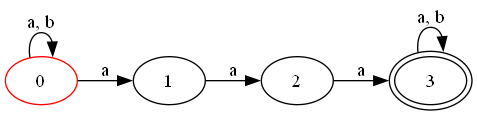

True


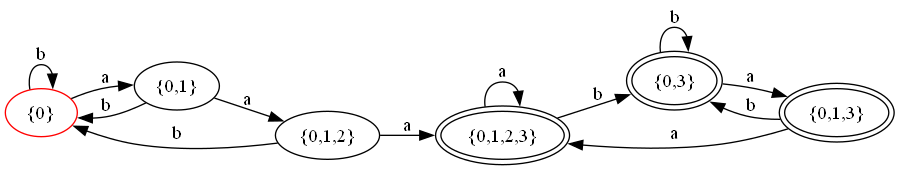

In [55]:
# Voici un test
#automate est l'automate construit plus haut a partir du fichier exempleAutomate.txt
automate.show()
auto_det = automate.determinisation()
print(auto_det.estDeterministe())
auto_det.show(2)

Automate :


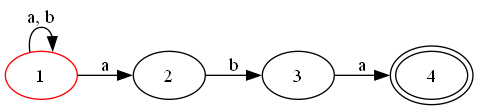

L'automate est déterministe :
True


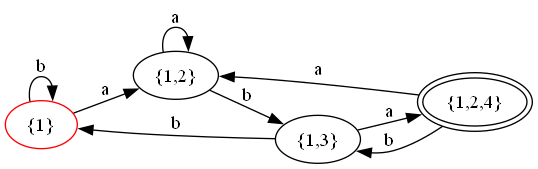

In [56]:
# Fournir un autre jeu de tests
## création d'états

S1_2 = State(1, True, False)
S2_2 = State(2, False, False)
S3_2 = State(3, False, False)
S4_2 = State(4, False, True)

## création de transitions

T1_2 = Transition(S1_2,"a",S1_2)
T2_2 = Transition(S1_2,"a",S2_2)
T3_2 = Transition(S2_2,"b",S3_2)
T4_2 = Transition(S3_2,"a",S4_2)
T5_2 = Transition(S1_2,"b",S1_2)

set_transitions_2 = {T1_2,T2_2,T3_2,T4_2, T5_2}

## création de l'automate
a2 = Automate(set_transitions_2)
print("Automate :")
a2.show()

a2_det = a2.determinisation()
print("L'automate est déterministe :")
print(a2_det.estDeterministe())
a2_det.show()


### 5. Constructions sur les automates réalisant  des opérations sur les langages acceptés <a class="anchor" id="sec5"></a>


#### 5.1 Opérations ensemblistes sur les langages <a class="anchor" id="sec5_1"></a>

1. Donner une définition de la fonction `complementaire` qui, étant donné un automate `auto` et un ensemble de caractères `Alphabet`, renvoie l'automate acceptant la langage complémentaire du langage accepté par `auto`. Ne pas modifier l'automate `auto`, mais construire un nouvel automate.

In [57]:
def complementaire(self, Alphabet):
    """ Automate x set[str] -> Automate
        rend  l'automate acceptant le complémentaire du langage de self
    """
    auto_det = self # Initialiser l'automate de travail avec l'automate actuel
    
    # Si l'automate n'est pas déterministe, le rendre déterministe
    if not self.estDeterministe():
        auto_det = self.determinisation()
        print("(On a dû déterminiser l'automate)")

    # Si l'automate résultant n'est pas complet, le rendre complet
    if not auto_det.estComplet(Alphabet):
        auto_det = auto_det.completeAutomate(Alphabet)
        print("(On a dû compléter l'automate)")

    # Créer une copie de l'automate déterministe pour le complémentaire
    auto_complement = copy.deepcopy(auto_det)

    # Inverser les états finaux : finaux deviennent non finaux et vice versa
    for state in auto_complement.allStates:
        state.fin = not state.fin

    return auto_complement

Automate.complementaire = complementaire   

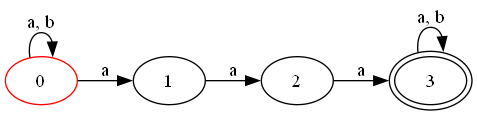

(On a dû déterminiser l'automate)


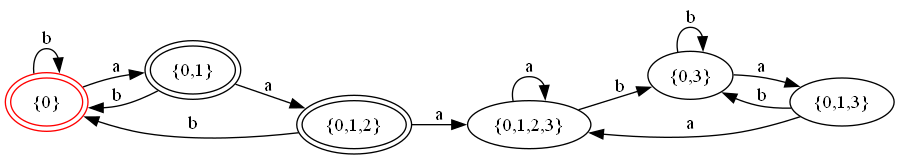

In [58]:
# Voici un test

automate = Automate.creationAutomate("ExemplesAutomates/exempleAutomate.txt")
automate.show()
Alphabet = {t.etiquette for t in auto.allTransitions}
auto_compl = automate.complementaire(Alphabet)
auto_compl.show(2)

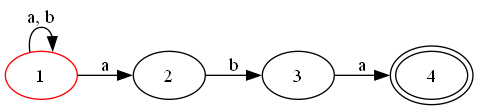

Voici le complémentaire :

(On a dû déterminiser l'automate)


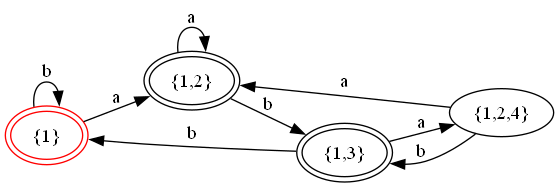

In [59]:
# Fournir un autre jeu de tests
a2.show()

print("Voici le complémentaire :\n")
Alphabet2 = {t.etiquette for t in a2.allTransitions}
a2_compl = a2.complementaire(Alphabet2)
a2_compl.show(1.5)


2. Donner une définition de la fonction `intersection` qui, étant donné deux automates `auto1` et `auto2`, renvoie l'automate acceptant l'intersection des langages acceptés par `auto1` et `auto2`.

L'automate construit ne doit pas avoir d'état non accessible depuis l'état initial.

In [ ]:
# Visualisation du fonctionnement de itertools.product
L1 = [1, 2, 3]
L2 = ["a", "b", "c"]
L = set(itertools.product(L1, L2))
print(L)

In [60]:
#A faire par l'étudiant

def intersection(self, auto):
    """ Automate x Automate -> Automate
    rend l'automate acceptant pour langage l'intersection des langages des deux automates
    """
    # Initialiser l'automate d'intersection
    auto_intersection = Automate(set(), set())
    new_states = {}

    # 1 : Créer tous les états combinés
    for s1 in self.allStates:
        for s2 in auto.allStates:
            # Un état combiné est initial si les deux états sont initiaux
            is_initial = s1.init and s2.init
            # Un état combiné est final si les deux états sont finaux
            is_final = s1.fin and s2.fin
            # Créer l'état combiné
            combined_state = State(len(new_states), is_initial, is_final, f"({s1.label},{s2.label})")
            new_states[(s1, s2)] = combined_state
            auto_intersection.addState(combined_state)

    # 2 : Ajouter les transitions combinées
    for (s1, s2), combined_state in new_states.items():
        for letter in {t.etiquette for t in self.allTransitions}.intersection(
                {t.etiquette for t in auto.allTransitions}):
            # Trouver les successeurs pour la lettre
            succ1 = {t.stateDest for t in self.getSetTransitionsFrom(s1) if t.etiquette == letter}
            succ2 = {t.stateDest for t in auto.getSetTransitionsFrom(s2) if t.etiquette == letter}

            for ns1 in succ1:
                for ns2 in succ2:
                    # Ajouter la transition combinée
                    target_state = new_states[(ns1, ns2)]
                    auto_intersection.addTransition(
                        Transition(combined_state, letter, target_state)
                    )

    # 3 : Supprimer les états inaccessibles après la construction
    accessible_states = set()
    stack = list(auto_intersection.getSetInitialStates())  # Parcours des états accessibles depuis les initiaux

    while stack:
        state = stack.pop()
        if state not in accessible_states:
            accessible_states.add(state)
            for t in auto_intersection.getSetTransitionsFrom(state):
                stack.append(t.stateDest)
 
    # Créer un nouvel automate filtré avec seulement les états accessibles
    filtered_states = accessible_states
    filtered_transitions = {t for t in auto_intersection.allTransitions
                            if t.stateSrc in accessible_states and t.stateDest in accessible_states}
    return Automate(set(filtered_transitions), set(filtered_states))

Automate.intersection = intersection  

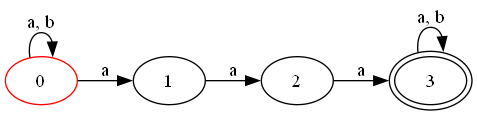

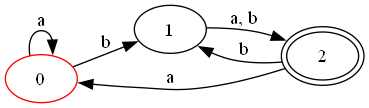

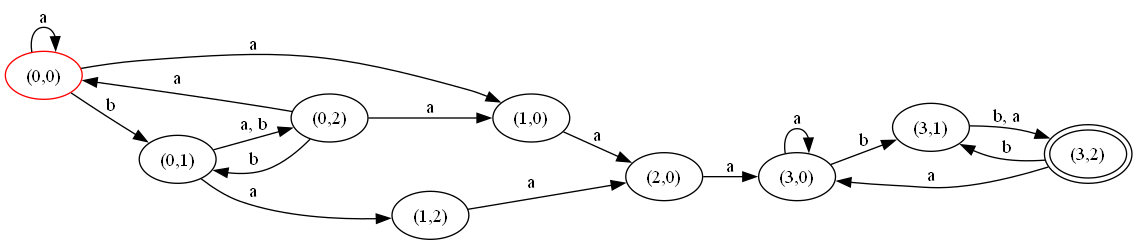

In [61]:
#Un premier test

#auto1 = Automate.creationAutomate("ExemplesAutomates/exempleAutomate.txt")
automate.show()
#auto2 = Automate.creationAutomate("ExemplesAutomates/exempleInter.txt")
# il faut avoir une variable auto2 contenant un automate
auto2.show()
inter = automate.intersection(auto2)
inter.show(2)

Automate 1 :


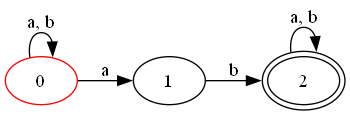

Automate 2:


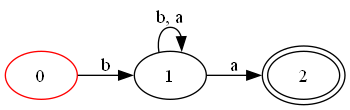

Intersection :


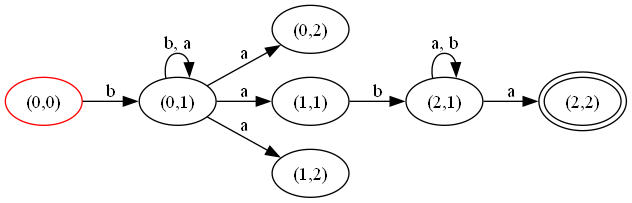

In [62]:
# Fournir d'autres tests
## automate 1

## création d'états
s0 = State(0, True, False)
s1= State(1, False, False)
s2 = State(2, False, True)

## création de transitions
T1_1 = Transition(s0,"a",s0)
T2_1 = Transition(s0,"a",s1)
T3_1 = Transition(s1,"b",s2)
T4_1 = Transition(s2,"b",s2)
T5_1 = Transition(s2,"a",s2)
T6_1 = Transition(s0,"b",s0)

set_transitions_1 = {T1_1,T2_1, T3_1, T4_1, T5_1, T6_1}

## création de l'automate
a1 = Automate(set_transitions_1)
print("Automate 1 :")
a1.show(0.7)

## automate 2

## création d'états
s0_4 = State(0, True, False)
s1_4 = State(1, False, False)
s2_4 = State(2, False, True)

## création de transitions
t1_4 = Transition(s0_4,"b",s1_4)
t2_4 = Transition(s1_4,"b",s1_4)
t3_4 = Transition(s1_4,"a",s1_4)
t4_4= Transition(s1_4,"a",s2_4)

set_transitions_4 = {t1_4,t2_4,t3_4,t4_4}

## création de l'automate
a4 = Automate(set_transitions_4)
print("Automate 2:")
a4.show()

inter_test = a1.intersection(a4)
print("Intersection :")
inter_test.show(2)


3. (Question facultative) Donner une définition de la fonction `union` qui, étant donné deux automates `auto1` `auto2`, renvoie l'automate acceptant comme langage l'union des langages acceptés par `auto1` et `auto2`.

In [63]:
#À faire par l'étudiant

def union (self, auto):
    """ Automate x Automate -> Automate
    rend l'automate acceptant pour langage l'union des langages des deux automates
    """
    # Tout d'abord on vérifie que les deux automates sont complets, s'ils ne le sont pas, on les complète
    
    # Générer les alphabets respectifs pour chaque automate
    alphabet_self = {t.etiquette for t in self.allTransitions}
    alphabet_auto = {t.etiquette for t in auto.allTransitions}

    if not self.estComplet(alphabet_self):
        self = self.completeAutomate(alphabet_self)
        print("On a dû compléter le premier automate, comme ceci : ")
        self.show()
    if not auto.estComplet(alphabet_auto):
        auto = auto.completeAutomate(alphabet_auto)
        print("On a dû compléter le deuxième automate, comme ceci : ")
        auto.show()

    
    auto_union = Automate(set(), set())  # on initialise l'automate union
    new_states = {}  # Dictionnaire pour associer les paires d'états combinés à des états uniques

    # état initial
    stack = []
    for s1 in self.getSetInitialStates():
        for s2 in auto.getSetInitialStates():
            is_final = s1.fin or s2.fin
            new_state = State(len(new_states), True, is_final, f"({s1.label},{s2.label})")
            new_states[(s1, s2)] = new_state
            auto_union.addState(new_state)
            stack.append((s1, s2))  # Ajouter à la pile les états initiaux combinés

    # Construire les transitions et les autres états
    while stack:
        s1, s2 = stack.pop()

        # Ajouter toutes les transitions possibles pour cet état combiné
        for letter in {t.etiquette for t in self.allTransitions}.union(
                {t.etiquette for t in auto.allTransitions}):
            # Trouver les successeurs dans les deux automates pour cette lettre
            succ1 = {t.stateDest for t in self.getSetTransitionsFrom(s1) if t.etiquette == letter}
            succ2 = {t.stateDest for t in auto.getSetTransitionsFrom(s2) if t.etiquette == letter}

            # Combiner les successeurs et ajouter les transitions correspondantes
            for ns1 in (succ1 or {s1}):
                for ns2 in (succ2 or {s2}):
                    if (ns1, ns2) not in new_states:
                        # Créer un nouvel état combiné
                        is_final = ns1.fin or ns2.fin
                        new_target_state = State(len(new_states), False, is_final, f"({ns1.label},{ns2.label})")
                        new_states[(ns1, ns2)] = new_target_state
                        auto_union.addState(new_target_state)
                        stack.append((ns1, ns2))  # Ajouter les successeurs à la pile

                    # Ajouter la transition
                    auto_union.addTransition(
                        Transition(new_states[(s1, s2)], letter, new_states[(ns1, ns2)])
                    )

    # Filtrer les états accessibles
    accessible_states = set()
    stack = list(auto_union.getSetInitialStates())  # Commencer avec l'état initial combiné unique
    while stack:
        state = stack.pop()
        if state not in accessible_states:
            accessible_states.add(state)
            for t in auto_union.getSetTransitionsFrom(state):
                stack.append(t.stateDest)

    # Filtrer les transitions pour ne conserver que celles entre états accessibles
    filtered_states = accessible_states
    filtered_transitions = {
        t for t in auto_union.allTransitions
        if t.stateSrc in accessible_states and t.stateDest in accessible_states
    }
    print("Union :")
    # Retourner l'automate
    return Automate(set(filtered_transitions), set(filtered_states))

Automate.union = union  

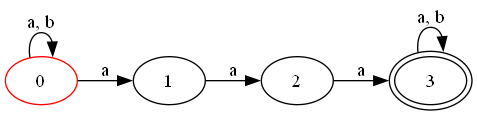

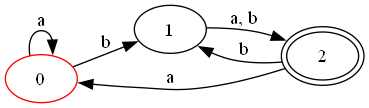

On a dû compléter le premier automate, comme ceci : 


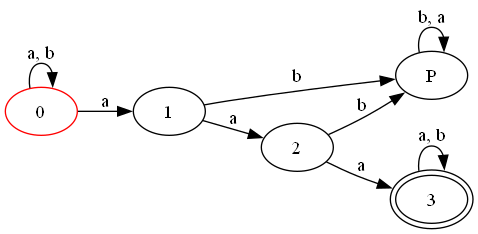

Union :


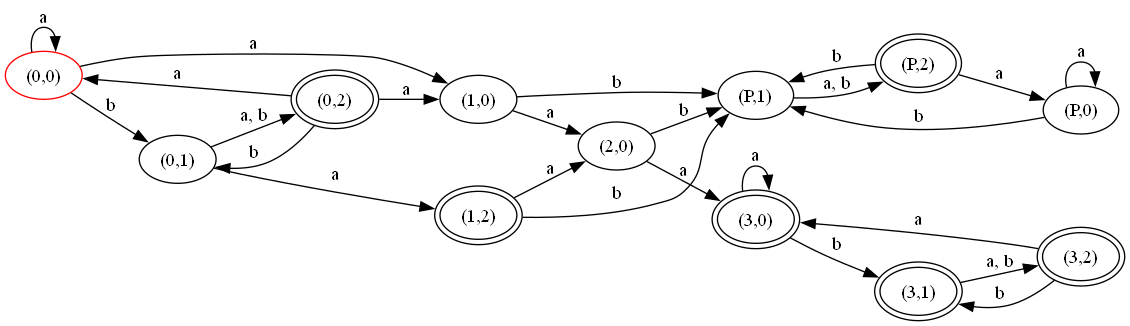

In [64]:
#Un premier test

automate.show()
auto2.show()
uni = automate.union(auto2)
uni.show(2)

Automate 1 :


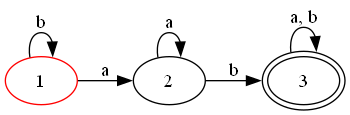

Automate 2:


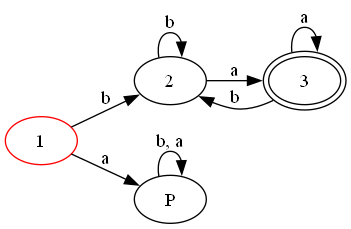

Union :


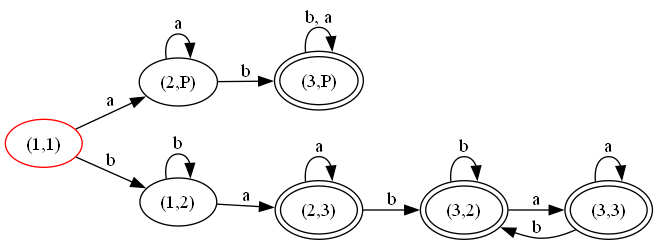

In [65]:
#Fournir d'autres tests
## automate 1

## création d'états
s1_5 = State(1, True, False)
s2_5= State(2, False, False)
s3_5 = State(3, False, True)

## création de transitions
T1_5 = Transition(s1_5,"b",s1_5)
T2_5 = Transition(s1_5,"a",s2_5)
T3_5 = Transition(s2_5,"a",s2_5)
T4_5 = Transition(s2_5,"b",s3_5)
T5_5 = Transition(s3_5,"a",s3_5)
T6_5 = Transition(s3_5,"b",s3_5)

set_transitions_5 = {T1_5,T2_5, T3_5, T4_5, T5_5, T6_5}

## création de l'automate
a5 = Automate(set_transitions_5)
print("Automate 1 :")
a5.show(0.7)

## automate 2

## création d'états
s1_6 = State(1, True, False)
s2_6 = State(2, False, False)
s3_6 = State(3, False, True)
s4_6 = State(4, False, False, "P")

## création de transitions
t1_6 = Transition(s1_6,"b",s2_6)
t2_6= Transition(s2_6,"b",s2_6)
t3_6 = Transition(s2_6,"a",s3_6)
t4_6= Transition(s3_6,"a",s3_6)
t5_6= Transition(s3_6,"b",s2_6)
t6_6= Transition(s1_6,"a",s4_6)
t7_6= Transition(s4_6,"a",s4_6)
t8_6= Transition(s4_6,"b",s4_6)

set_transitions_6 = {t1_6,t2_6,t3_6,t4_6,t5_6,t6_6,t7_6,t8_6 }

## création de l'automate
a6 = Automate(set_transitions_6)
print("Automate 2:")
a6.show()

union_test = a5.union(a6)
union_test.show(2)
 

#### 5.2 Opérations rationnelles sur les langages <a class="anchor" id="sec5_2"></a>

Programmer *une des deux* méthodes suivantes:

1. Donner une définition de la fonction `concatenation` qui, étant donné deux automates `auto1` et `auto2`, renvoie l'automate acceptant comme langage la concaténation des langages acceptés par `auto1` et `auto2`.

2. Donner une définition de la fonction `etoile` qui, étant donné un automate `auto`, renvoie l'automate acceptant comme langage l'étoile du langages accepté par `auto`.

In [66]:
# A faire par l'etudiant

def concatenation (self, auto):
    """ Automate x Automate -> Automate
    rend l'automate acceptant pour langage la concaténation des langages des deux automates
    """
    # Création d'un nouvel automate
    auto_concat = Automate(set(), set())
    # dictionnaires permettant de faire correspondre les états des automates originaux aux nouveaux états créés
    dict_self = {}
    dict_auto = {}
    # décalage utilisé pour éviter que les identifiants des états de auto entrent en conflit avec ceux de self
    dec = len(self.allStates)

    # Ajouter les états de self
    for state in self.allStates:
        new_state = State(state.id, state.init, state.fin, state.label)  # Les états finaux de self restent pour l'instant
        auto_concat.addState(new_state)
        dict_self[state] = new_state

    # Ajouter les états de auto avec un décalage
    for state in auto.allStates:
        new_state = State(state.id + dec, False, state.fin, state.label)  # Initial sera ajusté
        auto_concat.addState(new_state)
        dict_auto[state] = new_state

    # Ajouter les transitions internes à self
    for transition in self.allTransitions:
        auto_concat.addTransition(
            Transition(dict_self[transition.stateSrc], transition.etiquette, dict_self[transition.stateDest],)
        )

    # Ajouter les transitions internes à auto
    for transition in auto.allTransitions:
        auto_concat.addTransition(
            Transition(dict_auto[transition.stateSrc], transition.etiquette, dict_auto[transition.stateDest],)
        )

    # Ajouter les transitions entre self et auto
    for final_state in self.getSetFinalStates():
        for initial_state in auto.getSetInitialStates():
            for letter in {t.etiquette for t in self.allTransitions}:  # Alphabet de self
                auto_concat.addTransition(
                    Transition(
                        dict_self[final_state],  # Transitions partant d'un état final de self
                        letter,
                        dict_auto[initial_state],  # Vers les états initiaux de auto
                    )
                )

    # Conserver les transitions redirigées et ajuster les états finaux
    for transition in self.allTransitions:
        if transition.stateDest in self.getSetFinalStates():
            for initial_state in auto.getSetInitialStates():
                auto_concat.addTransition(
                    Transition(
                        dict_self[transition.stateSrc],  # L'état source reste le même
                        transition.etiquette,  # Même étiquette
                        dict_auto[initial_state],  # Rediriger vers l'état initial de auto
                    )
                )

    # Ajuster les états finaux
    for state in auto_concat.allStates:
        if state in dict_self.values():
            state.fin = False  # Les états finaux de self ne doivent plus être finaux
        elif state in dict_auto.values():
            original_state = next(
                (key for key, value in dict_auto.items() if value == state), None
            )
            state.fin = original_state.fin if original_state else False
    print("Concaténation :")

    return auto_concat

Automate.concatenation = concatenation

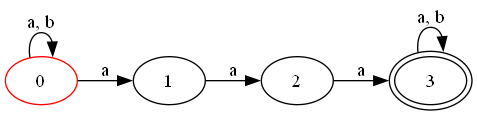

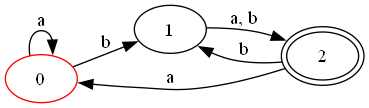

Concaténation :


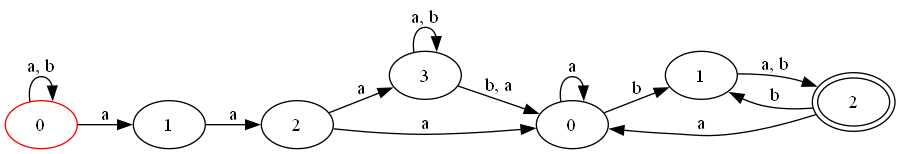

In [67]:
#Un premier test

automate.show()
auto2.show()
concat = automate.concatenation(auto2)
concat.show(2)

Automate 1 :


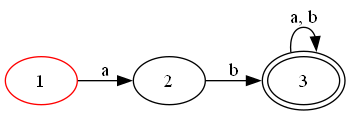

Automate 2:


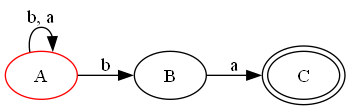

Concaténation :


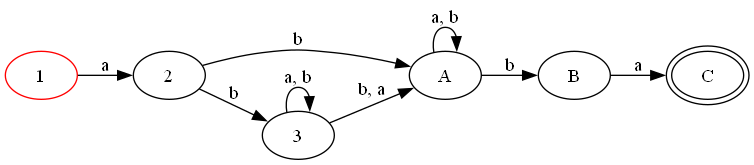

In [68]:
#Fournir d'autres tests
## création d'états
s1_7 = State(1, True, False)
s2_7= State(2, False, False)
s3_7 = State(3, False, True)

## création de transitions
T1_7 = Transition(s1_7,"a",s2_7)
T2_7 = Transition(s2_7,"b",s3_7)
T3_7 = Transition(s3_7,"a",s3_7)
T4_7 = Transition(s3_7,"b",s3_7)

set_transitions_7 = {T1_7,T2_7, T3_7, T4_7}

## création de l'automate
a7 = Automate(set_transitions_7)
print("Automate 1 :")
a7.show(0.7)

## automate 2

## création d'états
s1_8 = State(1, True, False, "A")
s2_8 = State(2, False, False, "B")
s3_8 = State(3, False, True, "C")

## création de transitions
t1_8 = Transition(s1_8,"b",s1_8)
t2_8= Transition(s1_8,"a",s1_8)
t3_8 = Transition(s1_8,"b",s2_8)
t4_8= Transition(s2_8,"a",s3_8)

set_transitions_8 = {t1_8,t2_8,t3_8,t4_8}

## création de l'automate
a8 = Automate(set_transitions_8)
print("Automate 2:")
a8.show()

concat2_test = a7.concatenation(a8)
concat2_test.show(1.5)


In [ ]:
def etoile (self):
    """ Automate  -> Automate
    rend l'automate acceptant pour langage l'étoile du langage de l'automate appelant
    """
   
    return 

Automate.etoile = etoile

In [ ]:
#Un premier test

automate.show()
autoetoile = automate.etoile()
autoetoile.show()

In [ ]:
#Fournir d'autres tests

#### 6 Application <a class="anchor" id="sec6"></a>

Cette partie du projet consiste à mettre en pratique l'utilisation d'un automate afin de rechercher des mots dans un texte.
La fonction suivante `alphabet_fichier`, étant donné un fichier textuel, renvoie l'ensemble des lettres présentes dans le texte du fichier.

In [ ]:
def alphabet_fichier(nom):
    """ Fichier -> set[str]
    renvoie l'ensemble des lettres apparaissant dans le texte du fichier. 
    Chaque chaine de l'ensemble construit est de taille 1."""
    # A : set[str]
    A = set()
    with open(nom) as fichier:
        # ligne : str
        for ligne in fichier:
            # c : str de taille 1
            for c in ligne:
                A.add(c)
    return A

In [ ]:
alphabet = alphabet_fichier("ExemplesAutomates/Extrait_Nicolas_Appert.txt")
print(alphabet)

Notre but consiste à extraire tous les nombres décimaux apparaissant dans un texte. Un nombre décimal vérifie la spécification suivante :
- ses premiers caractères sont des chiffres entre 0 et 9;
- le séparateur `,` apparait entre la partie entière et la partie décimale du nombre;
- ses derniers caractères sont des chiffres de 0 à 9.
Comme ces nombres apparaissent dans des chaîne de caractères, ils sont du type `str` dans notre contexte.

Ainsi `'012,4'`et `'0,12345'`sont des nombres décimaux, par contre `',123'`, `'123'` ou `'123.456'` n'en sont pas.

Donner une définition de la fonction `auto_flottant` qui, étant donné un ensemble de lettres `Alphabet`, renvoie l'automate acceptant comme langage l'ensemble des nombres décimaux.

Remarque :
- il faut que les nombres, sous forme de chaines de caractères extraites, représentent des nombres décimaux complets, c'est-à-dire qu'ils contiennent tous les chiffres consécutifs du texte. Par exemple, si le texte est 
`'abc123,4560def'` le seul nombre qui est extrait est `'123,4560'`;
- si le nombre décimal termine une ligne, il y a un cas particulier à gérer.

In [ ]:
# C'est une fonction, pas une méthode

def auto_flottant(Alphabet):
    """set[str] -> Automate
        prend en entrée en ensemble de chaines de caractères (chacune de taille 1),
        et renvoie l'automate acceptant les nombres décimaux."""

    return 

In [ ]:
# Jeu de test
alphabet = alphabet_fichier("ExemplesAutomates/Extrait_Nicolas_Appert.txt")
print(alphabet)
alphabet.add(' ')  ## permet de terminer les lignes par un espace (si jamais)
auto = auto_flottant(alphabet)
auto.show(300)

Donner une définition de la fonction `liste_flottants` prenant en entrée un automate ainsi qu'un fichier textuel et renvoyant la liste des nombres flottants présents dans le texte.

In [ ]:
def liste_flottants(auto, nom):
    """ Automate x Fichier -> list[str]
        renvoie la liste des nombres décimaux, sous forme de chaines de caractères, apparaissant
        dans l'ordre de lecture dans le fichier.
    """
    
    return

In [ ]:
# Jeu de test
liste_flottants(auto, "ExemplesAutomates/Extrait_Nicolas_Appert.txt") == ['1,020', '26,500', '3,600', '1,200', '2,040']